## 1. Import Required Libraries

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

from audio_processing.spectrogram import frame_to_seconds
from config import DEFAULT_SR
from controllers.database import connect, init_db
from controllers.match_service import MatchService


In [19]:
conn = connect()
cur = conn.cursor()

# Get song with the most fingerprints
cur.execute("SELECT song_id, COUNT(1) total FROM fingerprints group by song_id order by total desc limit 1")
song_with_most_fps, total_fps = cur.fetchone()
print(f"Song with most fingerprints has ID({song_with_most_fps}) with total of {total_fps} fingerprints")

# Total repeating hashes in that song
cur.execute("SELECT hash, COUNT(1) total FROM fingerprints where song_id = (?) group by hash order by total desc limit 15", (song_with_most_fps, ))
repeating_hashes = cur.fetchall()

# Create a DataFrame for the top 50 repeating hashes
hash_table = pd.DataFrame(repeating_hashes, columns=["Hash", "Count"])
display(hash_table)
print(hash_table.head())


Song with most fingerprints has ID(66) with total of 41896 fingerprints


,Hash,Count
0,9e95f86e97df106f4451,45
1,2c75c11abfe3f859ed08,30
2,7543fbf39ecbcdf8c7b4,29
3,b2dda0c61e7d7cd2d35e,29
4,836894cf0961d2df13a0,28
5,d3849cd9c516594ffe8d,28
6,5ee7a5ed2bf693ef425e,27
7,ddaf82b99f4ddf67f58b,26
8,187d021121d5ae9be43e,25
9,781abc018905a09c519a,25


                   Hash  Count
0  9e95f86e97df106f4451     45
1  2c75c11abfe3f859ed08     30
2  7543fbf39ecbcdf8c7b4     29
3  b2dda0c61e7d7cd2d35e     29
4  836894cf0961d2df13a0     28


Recognizing audio from 41896 fingerprints...

Total songs in DB: 79

 - The offset time frame with the most matches is: 0 with 41896 matches, which should match 0.0 seconds
 - The maximum offset time frame is: 14955 with 1 matches, which should match 347.25442176870746 seconds
 - The minimum offset time frame is: -14955 with 1 matches, which should match -347.25442176870746 seconds
Top offsets by count: [(0, 41896), (7480, 1215), (-7480, 1215), (2932, 972), (-2932, 972)]
Sum of top 3 offset counts: 44326


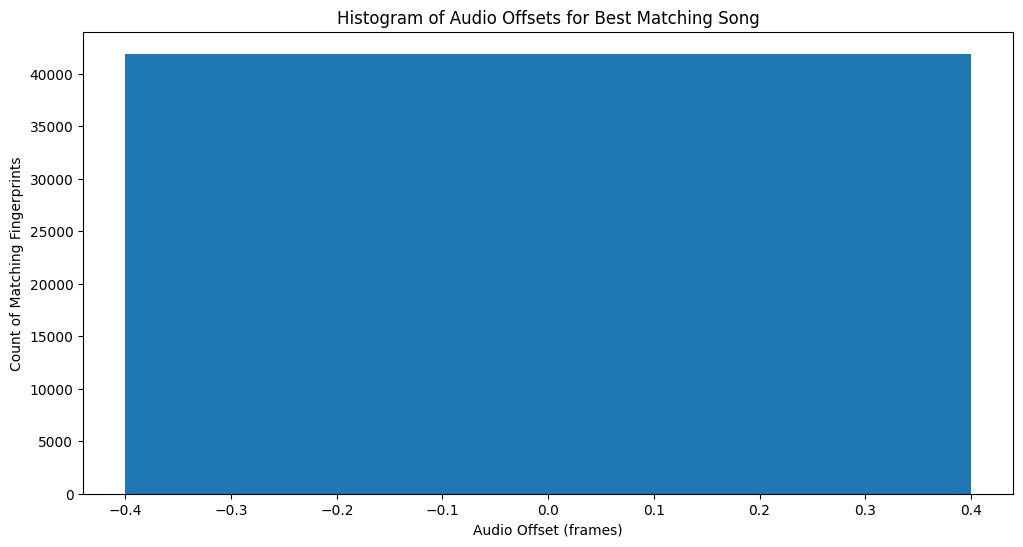

In [ ]:
match_service = MatchService()
match_service.conn = conn

cur.execute("SELECT hash, anchor_time, anchor_freq, target_time, target_freq FROM fingerprints where song_id = (?)", (song_with_most_fps, ))
all_fps = cur.fetchall()

match_for_enhanced, offset_histogram_for_enhanced = match_service.match_fingerprints(all_fps)

# Find the most common offset
most_common_offset = max(offset_histogram_for_enhanced.items(), key=lambda x: x[1])[0]
most_common_offset_seconds = frame_to_seconds(most_common_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The offset time frame with the most matches is: {most_common_offset} with {offset_histogram_for_enhanced[most_common_offset]} matches, which should match {most_common_offset_seconds} seconds")

max_offset = max(offset_histogram_for_enhanced.keys())
max_offset_seconds = frame_to_seconds(max_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The maximum offset time frame is: {max_offset} with {offset_histogram_for_enhanced[max_offset]} matches, which should match {max_offset_seconds} seconds")

min_offset = min(offset_histogram_for_enhanced.keys())
min_offset_seconds = frame_to_seconds(min_offset, hop_length=512, sample_rate=DEFAULT_SR)
print(f" - The minimum offset time frame is: {min_offset} with {offset_histogram_for_enhanced[min_offset]} matches, which should match {min_offset_seconds} seconds")

# Show the top 5 offsets by count
sorted_offsets = sorted(offset_histogram_for_enhanced.items(), key=lambda x: x[1], reverse=True)
print("Top offsets by count:", sorted_offsets[:5])

top_three_offsets = sorted_offsets[:3]

# Total count of matched fingerprints within the top 3 most common offsets
sum_of_top_three = sum(count for offset, count in top_three_offsets)
print(f"Sum of top 3 offset counts: {sum_of_top_three}")

plt.figure(figsize=(12, 6))
plt.bar([offset for offset, count in sorted_offsets[:1]],
        [count for offset, count in sorted_offsets[:1]])
plt.title("Histogram of Audio Offsets for Best Matching Song")
plt.xlabel("Audio Offset (frames)")
plt.ylabel("Count of Matching Fingerprints")
plt.show()
